<a href="https://colab.research.google.com/github/cruzysavage254/Data-Structrure__Assignment/blob/main/Employee.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
from google.colab import files
uploaded = files.upload()

Saving Employee_updated.csv to Employee_updated.csv


In [13]:
import os
os.listdir()

['.config', 'Employee_updated.csv', 'sample_data']

PART ONE : DATA LOADING AND OVERVIEW.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler,StandardScaler
plt.style.use("default")

In [14]:
df = pd.read_csv("Employee_updated.csv")
df.head(10)

,Unnamed: 0,First Name,Gender,Start Date,Last Login Time,Salary,Bonus %,Senior Management,Team
0,0,Douglas,Male,1993-08-06,12:42:00,97308,6.945,1,Marketing
1,1,Thomas,Male,1996-03-31,06:53:00,61933,4.170,1,Marketing
2,2,Maria,Female,1993-04-23,11:17:00,130590,11.858,0,Finance
3,3,Jerry,Male,2005-03-04,13:00:00,138705,9.340,1,Finance
4,4,Larry,Male,1998-01-24,16:47:00,101004,1.389,1,Client Services
5,5,Dennis,Male,1987-04-18,01:35:00,115163,10.125,0,Legal
6,6,Ruby,Female,1987-08-17,16:20:00,65476,10.012,1,Product
7,7,Ruby,Female,2015-07-20,10:43:00,45906,11.598,0,Finance
8,8,Angela,Female,2005-11-22,06:29:00,95570,18.523,1,Engineering
9,9,Frances,Female,2002-08-08,06:51:00,139852,7.524,1,Business Development


In [15]:
print("Shape:",df.shape)


print("\nColumns")
print(df.columns)


print("\nData Types")
print(df.dtypes)


print("\nSummary Statistics")
print(df.describe())


Shape: (1000, 9)

Columns
Index(['Unnamed: 0', 'First Name', 'Gender', 'Start Date', 'Last Login Time',
       'Salary', 'Bonus %', 'Senior Management', 'Team'],
      dtype='object')

Data Types
Unnamed: 0             int64
First Name            object
Gender                object
Start Date            object
Last Login Time       object
Salary                 int64
Bonus %              float64
Senior Management      int64
Team                  object
dtype: object

Summary Statistics
        Unnamed: 0         Salary      Bonus %  Senior Management
count  1000.000000    1000.000000  1000.000000        1000.000000
mean    499.500000   90662.181000    10.207555           0.468000
std     288.819436   32923.693342     5.528481           0.499225
min       0.000000   35013.000000     1.015000           0.000000
25%     249.750000   62613.000000     5.401750           0.000000
50%     499.500000   90428.000000     9.838500           0.000000
75%     749.250000  118740.250000    14.838000 

In [16]:
print(df.isnull().sum())

print("Duplicate rows:",df.duplicated().sum())

Unnamed: 0           0
First Name           0
Gender               0
Start Date           0
Last Login Time      0
Salary               0
Bonus %              0
Senior Management    0
Team                 0
dtype: int64
Duplicate rows: 0


PART TWO : HANDLING MISSING VALUES

In [17]:
df.isnull().sum()

,0
Unnamed: 0,0
First Name,0
Gender,0
Start Date,0
Last Login Time,0
Salary,0
Bonus %,0
Senior Management,0
Team,0


In [18]:
df["Gender"] = df["Gender"].fillna("Unknown")
df["Team"] = df["Team"].fillna("Unknown")

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

df = df.drop_duplicates()

df.isnull().sum()

,0
Unnamed: 0,0
First Name,0
Gender,0
Start Date,0
Last Login Time,0
Salary,0
Bonus %,0
Senior Management,0
Team,0


PART THREE : FEATURE ENGINEERING

In [20]:
df["Start Date"] = pd.to_datetime(df["Start Date"])

df["Senior Management"] = df["Senior Management"].astype(bool)

df["Start Year"] = df["Start Date"].dt.year

df["Years of Service"] = 2025 - df["Start Year"]

df["Gender"] = df["Gender"].astype("category")
df["Team"] = df["Team"].astype("category")

PARET 4A : UNIVARIATE ANALYSIS

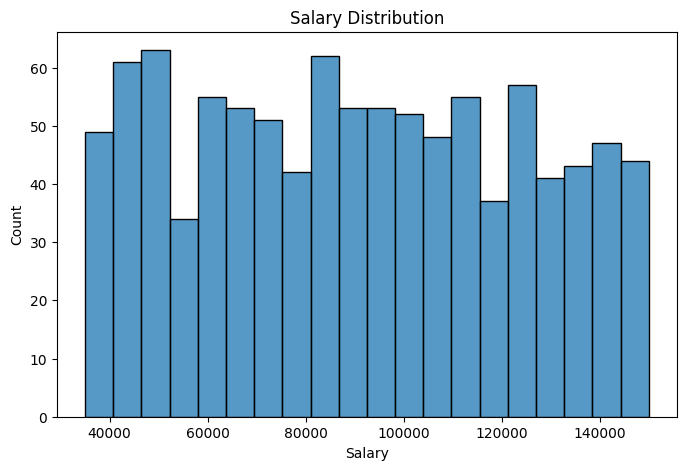

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df["Salary"], bins=20)
plt.title("Salary Distribution")
plt.show()

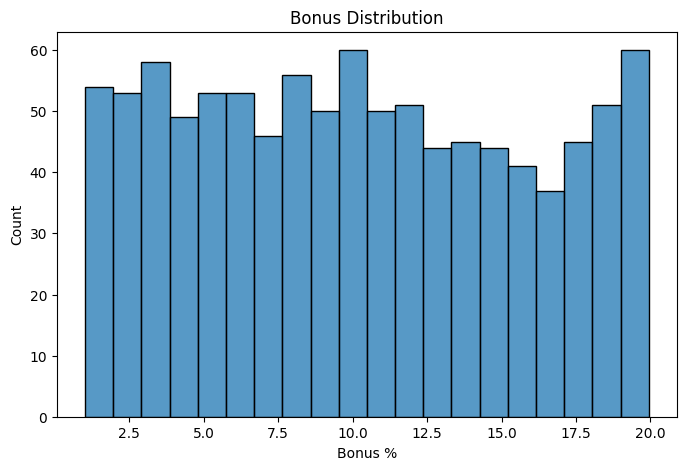

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(df["Bonus %"], bins=20)
plt.title("Bonus Distribution")
plt.show()

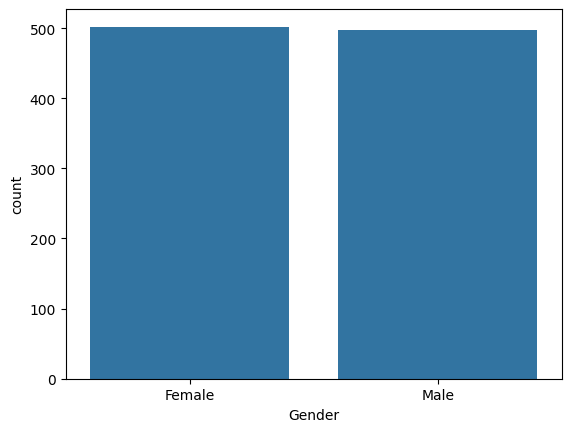

In [23]:
sns.countplot(data=df, x="Gender")
plt.show()

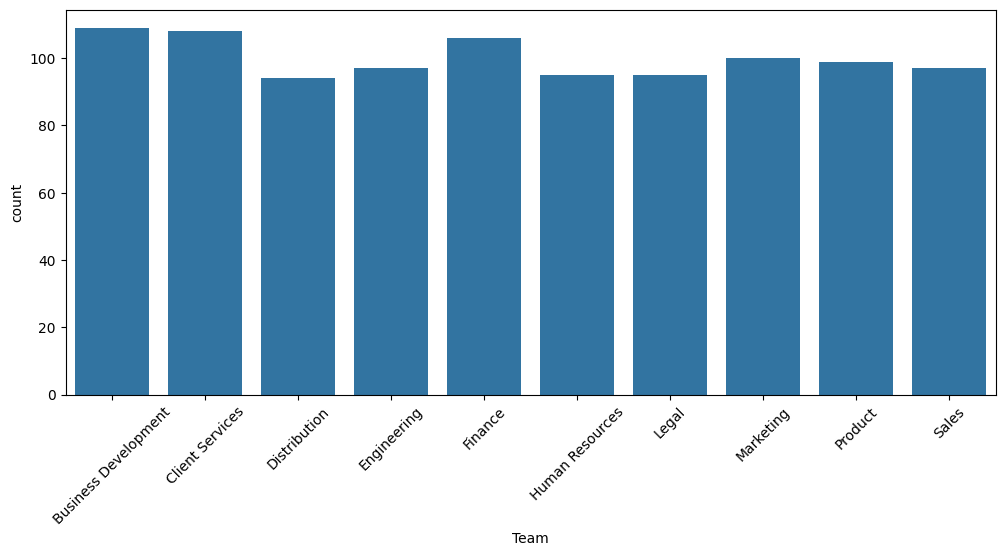

In [24]:
plt.figure(figsize=(12,5))
sns.countplot(data=df, x="Team")
plt.xticks(rotation=45)
plt.show()

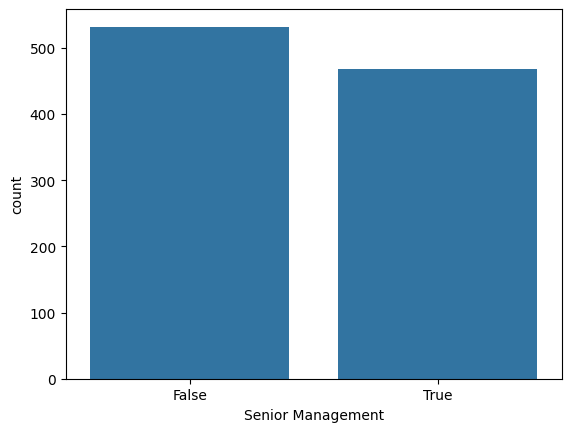

In [25]:
sns.countplot(data=df, x="Senior Management")
plt.show()

PART 4B : BIVARIATE ANALYSIS

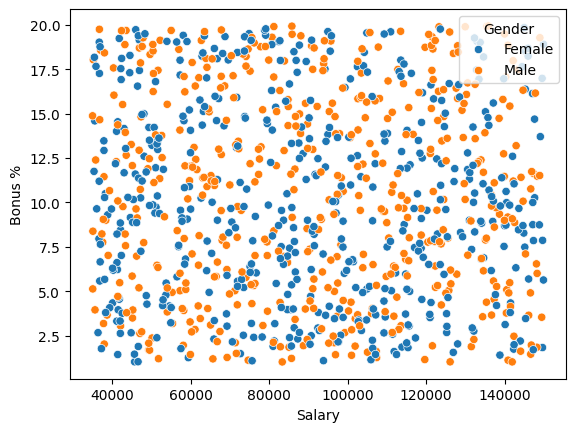

In [26]:
sns.scatterplot(
    data=df,
    x="Salary",
    y="Bonus %",
    hue="Gender"
)

plt.show()

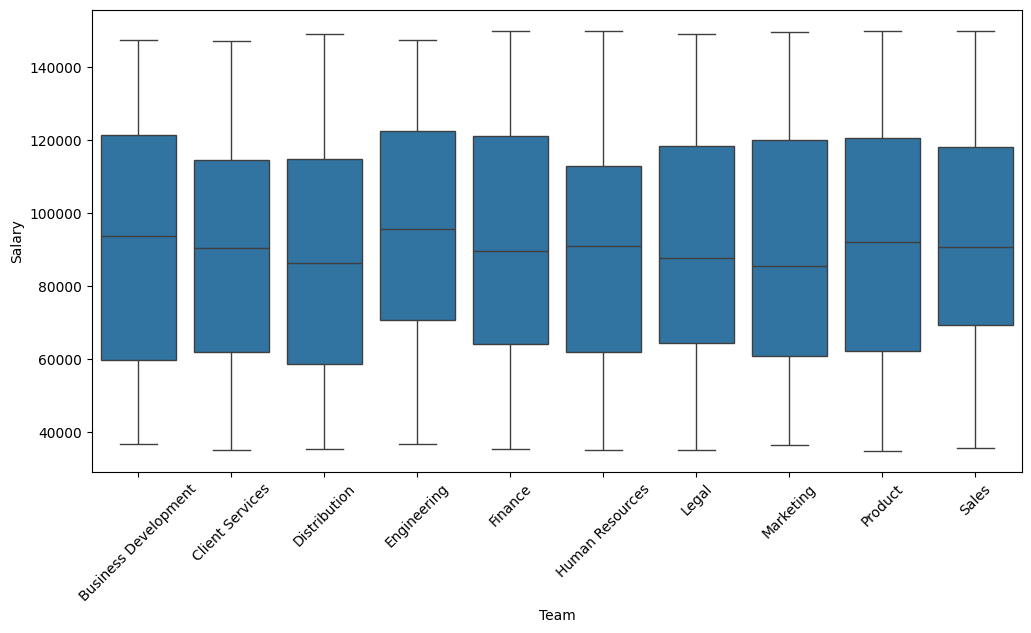

In [27]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="Team",
    y="Salary"
)

plt.xticks(rotation=45)
plt.show()

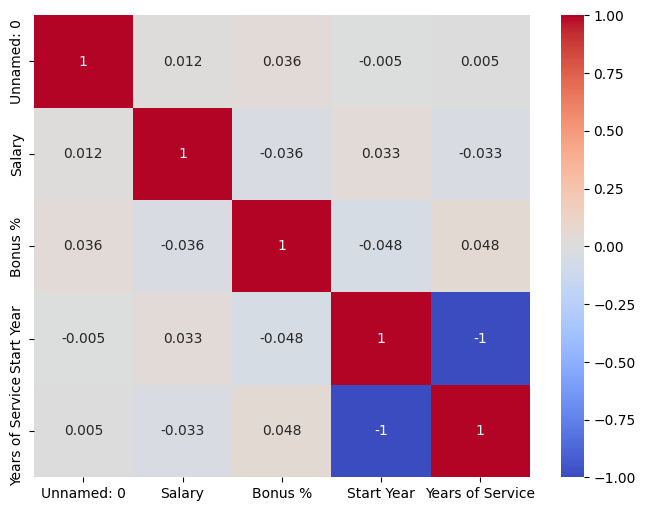

In [28]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

PART FIVE : GROUP ANALYSIS

In [30]:
df.groupby("Team")["Salary"]\
.mean()\
.sort_values(ascending=False)

/tmp/ipykernel_24870/2112086648.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Team")["Salary"]\


,Salary
Team,
Engineering,94904.814433
Finance,92478.509434
Business Development,91585.211009
Sales,91383.876289
Product,90629.060606
Marketing,90563.760000
Human Resources,89663.178947
Legal,89155.073684
Client Services,88367.111111


In [31]:
df.groupby("Gender")["Bonus %"].mean()

/tmp/ipykernel_24870/691205541.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Gender")["Bonus %"].mean()


,Bonus %
Gender,
Female,9.970321
Male,10.446695


In [32]:
df.groupby("Team")["Senior Management"].sum()

/tmp/ipykernel_24870/3476057389.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Team")["Senior Management"].sum()


,Senior Management
Team,
Business Development,58
Client Services,43
Distribution,38
Engineering,51
Finance,48
Human Resources,47
Legal,44
Marketing,50
Product,40


PART SIX : OUTLIERS

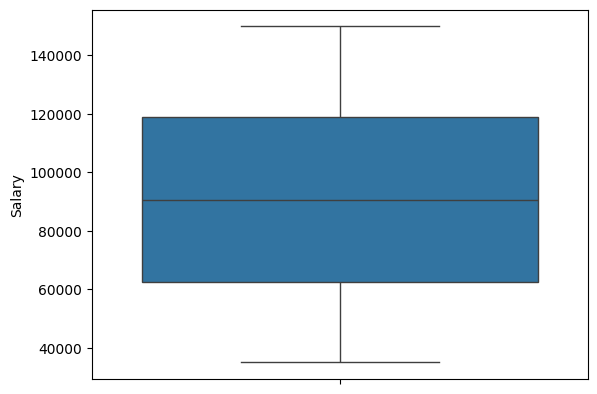

In [33]:
sns.boxplot(y=df["Salary"])
plt.show()

In [34]:
q75 = df["Salary"].quantile(0.75)

high_earners = df[df["Salary"] > q75]

print(len(high_earners))

250


PART SEVEN : SCALING

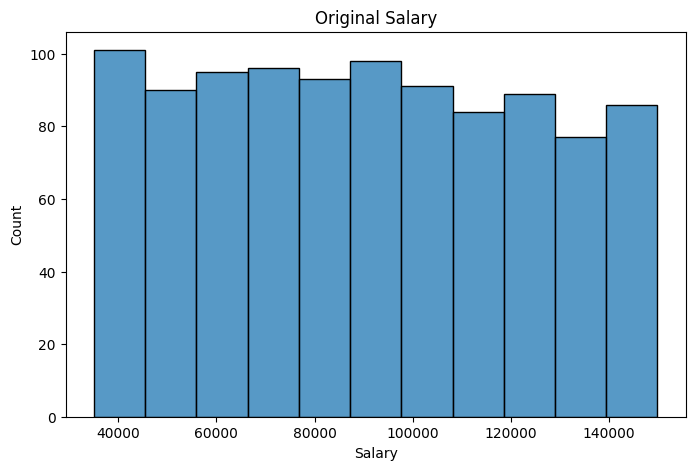

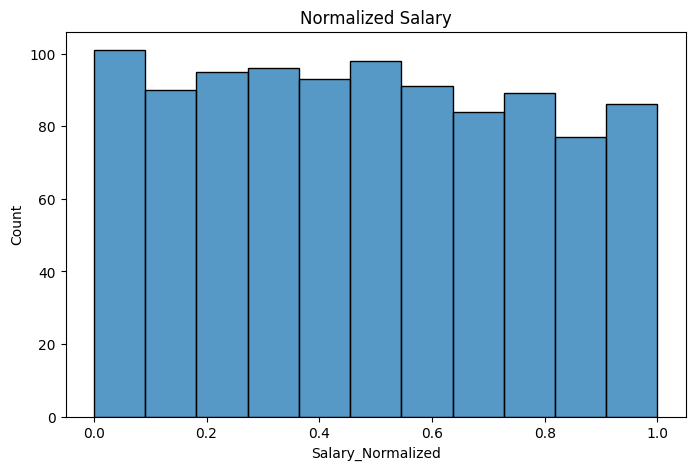

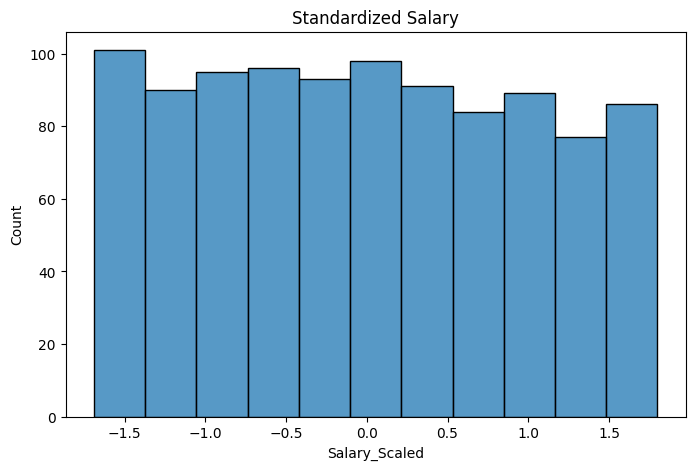

In [37]:
minmax = MinMaxScaler()
standard = StandardScaler()

df["Salary_Normalized"] = minmax.fit_transform(
    df[["Salary"]]
)

df["Salary_Scaled"] = standard.fit_transform(
    df[["Salary"]]
)

plt.figure(figsize=(8,5))
sns.histplot(df["Salary"])
plt.title("Original Salary")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df["Salary_Normalized"])
plt.title("Normalized Salary")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df["Salary_Scaled"])
plt.title("Standardized Salary")
plt.show()

PART EIGHT : KEY FINDINGS

1. Salary varies significantly across teams.
2. Gender distribution is relatively balanced.
3. Bonus percentage shows weak correlation with salary.
4. Employees with more years of service generally earn higher salaries.
5. A small number of employees are high-income outliers.

PART NINE : BONUS SECTION

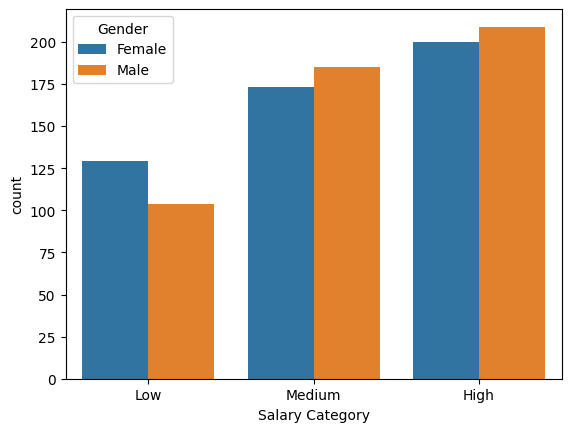

In [39]:
df["Salary Category"] = pd.cut(
    df["Salary"],
    bins=[0,60000,100000,float('inf')],
    labels=["Low","Medium","High"]
)

sns.countplot(
    data=df,
    x="Salary Category",
    hue="Gender"
)

plt.show()

df.to_csv(
    "cleaned_employees.csv",
    index=False
)

PART TEN AND ELEVEN : MACHINE LEARNING

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


df_ml = df.copy()

le_gender = LabelEncoder()
le_team = LabelEncoder()

df_ml["Gender"] = le_gender.fit_transform(df_ml["Gender"])
df_ml["Team"] = le_team.fit_transform(df_ml["Team"])
df_ml["Salary Category"] = LabelEncoder().fit_transform(
    df_ml["Salary Category"]
)


X = df_ml[
    ["Gender",
     "Team",
     "Bonus %",
     "Years of Service"]
]

y = df_ml["Salary Category"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, pred))

print(classification_report(
      y_test, pred))

Accuracy: 0.375
              precision    recall  f1-score   support

           0       0.44      0.55      0.49        83
           1       0.20      0.08      0.11        51
           2       0.33      0.38      0.35        66

    accuracy                           0.38       200
   macro avg       0.32      0.34      0.32       200
weighted avg       0.34      0.38      0.35       200

